# DEM & ACC EDA Notebook

This notebook performs exploratory data analysis (EDA) for a watershed-level summary dataset derived from HydroSHEDS.
This is adapted from the code used for basin with very minor change.

**Expected file:** `watershed_dem_acc_stats.csv`

**Expected columns (at minimum):** `ws_id, dem_min, dem_max, dem_mean, dem_std, dem_median, acc_min, acc_max, acc_mean, acc_std, acc_median`

---

### Engineered features (computed in this notebook)  
- **`relief`** = `dem_max – dem_min` → vertical range of the watershed (steepness).  
- **`elev_range_iqr_proxy`** = `dem_max – dem_median` → how extreme the highest peaks are compared to the typical elevation.  
- **`flow_density_proxy`** = `acc_mean ÷ relief` → normalized drainage concentration (how integrated the river network is, relative to steepness).  

---

👉 Use this framework to identify which watersheds lean more toward **flash floods**, **riverine floods**, or smaller localized events. 

In [1]:
# --- Setup ---
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import geopandas as gpd
from shapely.errors import ShapelyDeprecationWarning
import warnings
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)

## 1. Load data

In [2]:
# Path to your CSV. Change if needed.
CSV_PATH = "../../data/boundaries/processed/watershed_dem_acc_stats.csv"

if not os.path.exists(CSV_PATH):
    print(f"⚠️ Could not find {CSV_PATH}. Please upload it to the same directory as this notebook or update CSV_PATH.")
else:
    print(f"Found data at: {os.path.abspath(CSV_PATH)}")

df = pd.read_csv(CSV_PATH) if os.path.exists(CSV_PATH) else pd.DataFrame()
df.head() if not df.empty else pd.DataFrame({"message": ["Upload your CSV and re-run this cell."]})


Found data at: /Users/liuq13/bhutan_climate_modeling/data/boundaries/processed/watershed_dem_acc_stats.csv


,ws_id,dem_min,dem_max,dem_mean,dem_std,dem_median,acc_min,acc_max,acc_mean,acc_std,acc_median
0,1,2690.0,4483.0,3871.240740,350.309780,3952.0,1.0,8601.0,77.982920,564.187823,3.0
1,2,3433.0,6141.0,4576.269356,479.646825,4593.0,1.0,36739.0,113.261979,1023.329133,4.0
2,3,3409.0,6447.0,4636.337642,468.489801,4651.0,1.0,36822.0,155.080198,1498.649756,4.0
3,4,3395.0,6209.0,4970.112385,500.694309,5033.0,1.0,36840.0,171.237076,1710.621052,4.0
4,5,3885.0,7026.0,4984.136151,702.877441,4817.0,1.0,10835.0,121.560912,762.528089,4.0


## 2. Quick overview

In [3]:
if df.empty:
    print("Dataframe is empty. Skip this section until data is loaded.")
else:
    print("Shape:", df.shape)
    print("\nColumns:", df.columns.tolist())
    print("\nDTypes:")
    print(df.dtypes)
    print("\nMissing values per column:")
    print(df.isna().sum())
    display(df.describe(include='all').T)


Shape: (186, 11)

Columns: ['ws_id', 'dem_min', 'dem_max', 'dem_mean', 'dem_std', 'dem_median', 'acc_min', 'acc_max', 'acc_mean', 'acc_std', 'acc_median']

DTypes:
ws_id           int64
dem_min       float64
dem_max       float64
dem_mean      float64
dem_std       float64
dem_median    float64
acc_min       float64
acc_max       float64
acc_mean      float64
acc_std       float64
acc_median    float64
dtype: object

Missing values per column:
ws_id         0
dem_min       0
dem_max       0
dem_mean      0
dem_std       0
dem_median    0
acc_min       0
acc_max       0
acc_mean      0
acc_std       0
acc_median    0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
ws_id,186.0,93.500000,53.837719,1.000000,47.250000,93.500000,139.750000,1.860000e+02
dem_min,186.0,1281.419355,1090.082802,89.000000,273.000000,950.000000,2146.500000,3.891000e+03
dem_max,186.0,4111.419355,1371.633867,1193.000000,3091.000000,4238.000000,5028.500000,7.065000e+03
dem_mean,186.0,2578.477429,1302.681498,418.601171,1491.979259,2575.947421,3561.367701,5.052531e+03
dem_std,186.0,568.124383,156.558339,249.167555,463.942264,553.743588,681.586928,1.012614e+03
dem_median,186.0,2574.142473,1347.501958,352.000000,1489.000000,2585.000000,3547.750000,5.159000e+03
acc_min,186.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00
acc_max,186.0,356155.489247,609966.123931,1609.000000,30329.250000,84700.500000,378906.500000,3.756086e+06
acc_mean,186.0,1780.001228,4394.499946,25.692851,149.213178,239.051685,1368.509311,4.449635e+04
acc_std,186.0,21140.868296,45005.696213,105.566681,1388.160268,2771.813806,19505.873294,4.062180e+05


## 3. Feature engineering

In [5]:
if not df.empty:
    df['relief'] = df['dem_max'] - df['dem_min']
    df['elev_range_iqr_proxy'] = df['dem_max'] - df['dem_median']  # simple spread proxy
    # Flow density proxy: acc_mean / relief (avoid div by zero)
    df['flow_density_proxy'] = df['acc_mean'] / (df['relief'].replace(0, np.nan))
    display(df[['ws_id','relief','elev_range_iqr_proxy','flow_density_proxy']])


,ws_id,relief,elev_range_iqr_proxy,flow_density_proxy
0,1,1793.0,531.0,0.043493
1,2,2708.0,1548.0,0.041825
2,3,3038.0,1796.0,0.051047
3,4,2814.0,1176.0,0.060852
4,5,3141.0,2209.0,0.038701
...,...,...,...,...
181,182,2146.0,1468.0,0.048925
182,183,1868.0,1111.0,0.048277
183,184,2384.0,1407.0,0.062548
184,185,1610.0,1349.0,0.027814


## Engineered Features  

### 1. `relief`  
- **Formula:** `dem_max – dem_min`  
- **Meaning:** Vertical range of elevation in a basin (meters).  
- **Logic:** High relief = steeper terrain, stronger gravitational force on water, faster runoff → more prone to **flash floods**.  

---

### 2. `elev_range_iqr_proxy`  
- **Formula:** `dem_max – dem_median`  
- **Meaning:** How extreme the highest peaks are compared to the “typical” elevation.  
- **Logic:** Large values suggest high headwaters above the main valley → can indicate potential for **glacier- or lake-fed flooding (GLOF)** because water stored at high elevations can suddenly discharge downslope.  

---

### 3. `flow_density_proxy`  
- **Formula:** `acc_mean ÷ relief`  
- **Meaning:** Average flow accumulation normalized by elevation range.  
- **Logic:**  
  - High values → drainage network is dense and well-integrated for the terrain → favors **riverine flooding** (large downstream flows).  
  - Low values → less integrated drainage for the same relief → water concentrates locally in steep valleys → favors **flash floods**.  

 


## 5. Scatter plot: Relief vs Flow Density Proxy

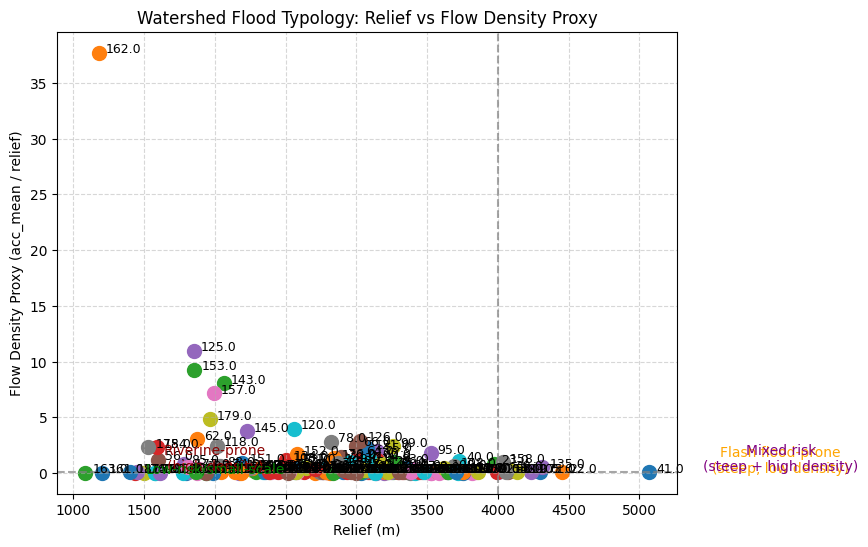

In [6]:
plt.figure(figsize=(8,6))

for i, row in df.iterrows():
    plt.scatter(row['relief'], row['flow_density_proxy'], s=100)
    plt.text(row['relief']+50, row['flow_density_proxy']+0.002, 
             row['ws_id'], fontsize=9)

plt.xlabel("Relief (m)")
plt.ylabel("Flow Density Proxy (acc_mean / relief)")
plt.title("Watershed Flood Typology: Relief vs Flow Density Proxy")

# Add interpretive zones (rough)
plt.axhline(0.1, color="grey", linestyle="--", alpha=0.7)
plt.axvline(4000, color="grey", linestyle="--", alpha=0.7)
plt.text(2000, 0.25, "Riverine-prone\n(high density)", ha="center", fontsize=10, color="darkred")
plt.text(2000, 0.05, "Low-risk/small-scale", ha="center", fontsize=10, color="green")
plt.text(6000, 0.05, "Flash flood-prone\n(steep, low density)", ha="center", fontsize=10, color="orange")
plt.text(6000, 0.25, "Mixed risk\n(steep + high density)", ha="center", fontsize=10, color="purple")

plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


## Interpreting the 2×2 Plot  

The scatter plot places **Relief (x-axis)** against **Flow Density Proxy (y-axis)**:  

- **X-axis (Relief):**  
  - Low → flatter terrain.  
  - High → steep, mountainous terrain.  

- **Y-axis (Flow Density Proxy):**  
  - Low → weakly integrated drainage (local runoff dominates).  
  - High → strongly integrated drainage (large rivers dominate).  

This creates four interpretive zones:  

|                | **Low Flow Density Proxy** | **High Flow Density Proxy** |
|----------------|-----------------------------|-----------------------------|
| **Low Relief** | **Small-scale / localized floods** → flatter basins, weak drainage (e.g., Merak_Sakteng). | Rare case, could mean concentrated drainage in relatively flat basin. |
| **High Relief** | **Flash flood-prone** → steep slopes, but drainage not well integrated (e.g., Jaldhakha, Aiechhu). | **Riverine / mixed floods** → steep slopes *and* strong drainage integration, combining flashiness upstream with large downstream floods (e.g., Drangmechhu, Punatsangchhu). |

---

👉 **Takeaway:**  
- Relief tells you about **how fast water moves** (steepness).  
- Flow density proxy tells you about **how connected the drainage is** (extent of river network).  
- Putting them together distinguishes between **flash floods** (steep but fragmented) and **riverine floods** (steep + well integrated). 

## 6. Choropleth Maps: Spatial Patterns of Relief and Flow Density Proxy  

In this section, we map the engineered features back onto basin geometries.  
- **Relief map** highlights which basins are steep vs relatively flat.  
- **Flow Density Proxy map** highlights how concentrated drainage networks are across basins.  

These continuous choropleths allow quick visual identification of areas that may lean more toward **flash-flood susceptibility** (high relief, low density) or **riverine flood susceptibility** (high relief, high density).


In [7]:
# --- Load basin shapefile ---
basins_gdf = gpd.read_file("../../data/boundaries/186_watershed/186 Watershed boundary.shp")
basins_gdf

,f_area,ws_id,area_ha,area_ha_1,SHAPE__Len,SHAPE__Are,geometry
0,1.403314e+08,1,14033.1356069597,14033.135607,88962.631299,1.783218e+08,"POLYGON ((10245897.804 3155396.599, 10245640.9..."
1,1.069433e+08,2,10694.331035308,10694.331035,72762.793824,1.380322e+08,"POLYGON ((9990796.024 3272558.723, 9990916.261..."
2,1.634449e+08,3,16436.0007344264,16436.000734,87853.120695,2.119142e+08,"POLYGON ((9977078.645 3269692.821, 9977264.969..."
3,2.076810e+08,4,20768.1036079112,20768.103608,100646.751220,2.681361e+08,"POLYGON ((9997299.005 3278803.177, 9997517.596..."
4,9.158350e+07,5,9158.35047410094,9158.350474,62076.446669,1.181974e+08,"POLYGON ((10034395.122 3273465.314, 10034625.4..."
...,...,...,...,...,...,...,...
181,2.232692e+08,182,22327.0066383582,22327.006638,103077.140454,2.819314e+08,"POLYGON ((10050319.404 3124664.06, 10050319.33..."
182,9.247798e+07,183,9325.24891666983,9325.248917,68574.466350,1.178372e+08,"POLYGON ((10060456.944 3125233.01, 10060456.84..."
183,3.099220e+08,184,30992.2044932785,30992.204493,143491.728489,3.911354e+08,"POLYGON ((10186245.917 3126672.804, 10186245.5..."
184,6.034296e+07,185,6034.29619042508,6034.296190,57640.400766,7.609741e+07,"POLYGON ((10222792.938 3107687.845, 10221910.8..."


In [8]:
# Merge with your basin EDA dataframe
# Assumes your `df` has a "basin" column matching shapefile attribute (adjust as needed)
g = basins_gdf.merge(df[['ws_id','relief','flow_density_proxy']], on='ws_id')

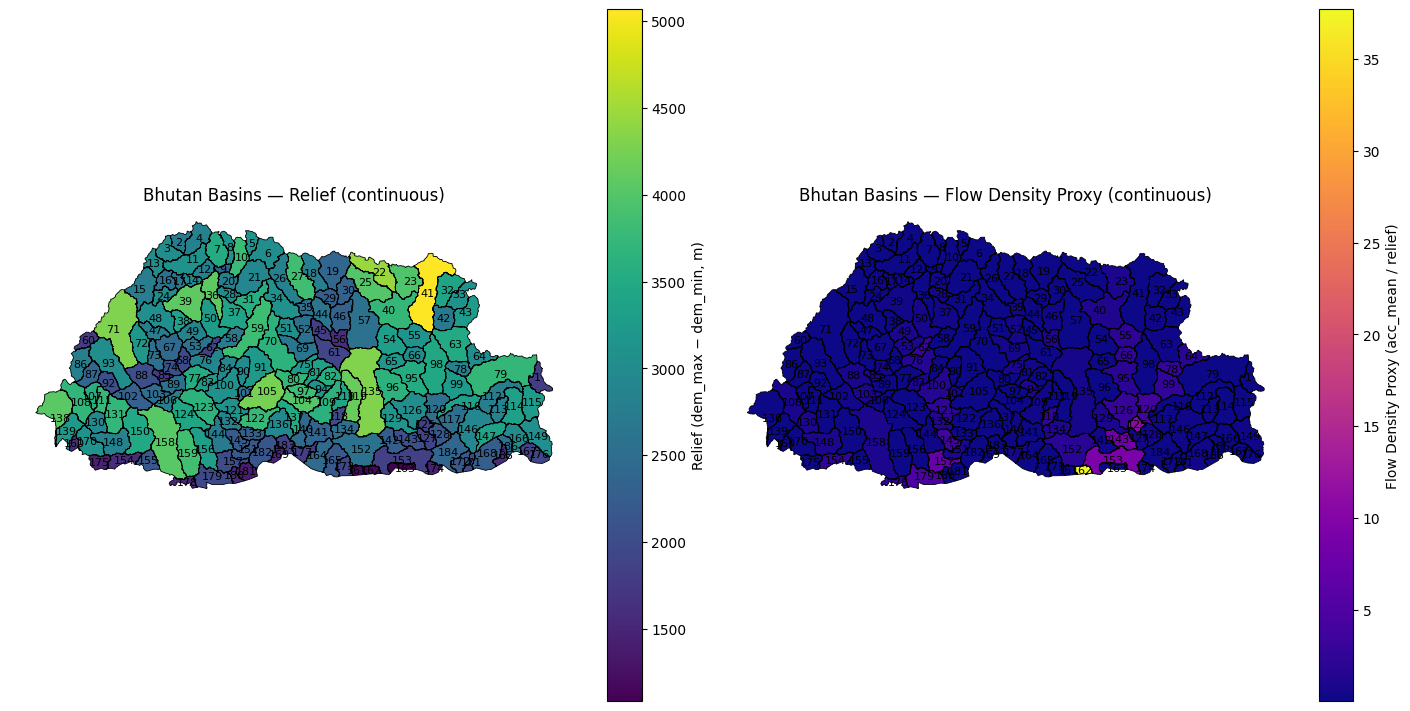

In [11]:
# Assumes you already have:
# g  -> a GeoDataFrame with columns: ['basin', 'geometry', 'relief', 'flow_density_proxy', ...]
# CRS can be anything; we won't reproject unless you need to.

# --- Safety: coerce to numeric in case they came in as objects ---
g = g.copy()
for col in ["relief", "flow_density_proxy"]:
    g[col] = pd.to_numeric(g[col], errors="coerce")

# --- Label points placed inside each polygon (works better than centroids on concave shapes) ---
pts = g.geometry.representative_point()
g["lab_x"] = pts.x
g["lab_y"] = pts.y

# --- Side-by-side continuous maps (no binning) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)

# Map 1: Relief
g.plot(
    column="relief",
    cmap="viridis",
    linewidth=0.6,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "Relief (dem_max − dem_min, m)"},
    ax=axes[0]
)
for _, row in g.iterrows():
    axes[0].text(row["lab_x"], row["lab_y"], str(row["ws_id"]), fontsize=8, ha="center", va="center")
axes[0].set_title("Bhutan Basins — Relief (continuous)")
axes[0].axis("off")

# Map 2: Flow Density Proxy
g.plot(
    column="flow_density_proxy",
    cmap="plasma",   # choose any continuous cmap you like
    linewidth=0.6,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "Flow Density Proxy (acc_mean / relief)"},
    ax=axes[1]
)
for _, row in g.iterrows():
    axes[1].text(row["lab_x"], row["lab_y"], str(row["ws_id"]), fontsize=8, ha="center", va="center")
axes[1].set_title("Bhutan Basins — Flow Density Proxy (continuous)")
axes[1].axis("off")

plt.show()